In [335]:
import pandas as pd

df = pd.read_csv("311_Service_Requests_from_2020_to_Present_20260614.csv")
df["Created Date"] = pd.to_datetime(df["Created Date"])

# Drop June 2026 — incomplete month
df = df[~((df["Created Date"].dt.year == 2026) & (df["Created Date"].dt.month == 6))]

# Keep only rodent-related complaints
rodent_keywords = ["rodent", "rat", "mouse", "mice"]
desc_cols = ["Problem (formerly Complaint Type)", "Problem Detail (formerly Descriptor)", "Additional Details"]
rodent_mask = df[desc_cols].apply(lambda col: col.str.lower().str.contains("|".join(rodent_keywords), na=False)).any(axis=1)
df = df[rodent_mask]

print(df.shape)
df["Problem (formerly Complaint Type)"].value_counts()

(254296, 44)


Problem (formerly Complaint Type)
Rodent                        229812
Food Establishment             12001
Maintenance or Facility        10906
School Maintenance              1576
Transfer Station Complaint         1
Name: count, dtype: int64

In [336]:
# What location types exist and how many complaints each?
df["Location Type"].value_counts()

Location Type
3+ Family Apt. Building                 108538
1-2 Family Dwelling                      42583
Other (Explain Below)                    32447
Commercial Building                      12528
3+ Family Mixed Use Building             12396
Restaurant/Bar/Deli/Bakery               10933
Park                                      8568
Vacant Lot                                3790
Construction Site                         3486
1-2 Family Mixed Use Building             3463
Vacant Building                           2636
Parking Lot/Garage                        2483
Street/Curbside                           2337
School                                    1538
Catch Basin/Sewer                         1379
Sidewalk                                  1146
Public Garden                              687
Street                                     562
Single Room Occupancy (SRO)                402
Government Building                        383
School/Pre-School                          360

In [337]:
# Filter to residential location types only
residential_types = [
    "3+ Family Apt. Building",
    "1-2 Family Dwelling",
    "3+ Family Mixed Use Building",
    "1-2 Family Mixed Use Building",
]

res = df[df["Location Type"].isin(residential_types)].copy()
print(f"Residential complaints: {len(res):,} out of {len(df):,} ({len(res)/len(df)*100:.1f}%)")
res["Location Type"].value_counts()

Residential complaints: 166,980 out of 254,296 (65.7%)


Location Type
3+ Family Apt. Building          108538
1-2 Family Dwelling               42583
3+ Family Mixed Use Building      12396
1-2 Family Mixed Use Building      3463
Name: count, dtype: int64

In [338]:
# Add year-month column
res["year_month"] = res["Created Date"].dt.to_period("M")

# Monthly residential complaints by borough
monthly = res.groupby(["year_month", "Borough"]).size().unstack(fill_value=0)
monthly.tail()

Borough,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Unspecified
year_month,,,,,,
2026-01,225,397,306,135,32,0
2026-02,206,338,241,155,17,0
2026-03,288,618,389,322,63,0
2026-04,302,646,363,316,66,0
2026-05,377,866,492,438,120,0


In [339]:
# Which zip codes have the most residential rodent complaints?
top_zips = res.groupby(["Incident Zip", "Borough"]).size().reset_index(name="complaints")
top_zips = top_zips.sort_values("complaints", ascending=False)
top_zips.head(20)

,Incident Zip,Borough,complaints
32,10035.0,MANHATTAN,6317
114,11216.0,BROOKLYN,3984
124,11226.0,BROOKLYN,3876
119,11221.0,BROOKLYN,3852
22,10025.0,MANHATTAN,3591
136,11238.0,BROOKLYN,3306
162,11385.0,QUEENS,3077
134,11237.0,BROOKLYN,2897
130,11233.0,BROOKLYN,2827
78,10467.0,BRONX,2684


In [340]:
# Residential complaints by borough — totals and share
borough_res = res.groupby("Borough").size().reset_index(name="complaints")
borough_res["pct"] = (borough_res["complaints"] / borough_res["complaints"].sum() * 100).round(1)
borough_res.sort_values("complaints", ascending=False)

,Borough,complaints,pct
1,BROOKLYN,60828,36.4
2,MANHATTAN,41994,25.1
0,BRONX,30457,18.2
3,QUEENS,27789,16.6
4,STATEN ISLAND,5911,3.5
5,Unspecified,1,0.0


In [341]:
# Breakdown: what type of rodent complaint at residential addresses?
res["Problem Detail (formerly Descriptor)"].value_counts()

Problem Detail (formerly Descriptor)
Rat Sighting                    101526
Condition Attracting Rodents     31778
Signs of Rodents                 19717
Mouse Sighting                   13896
Rodent Bite - PCS Only              44
Rodents/Insects/Garbage             19
Name: count, dtype: int64

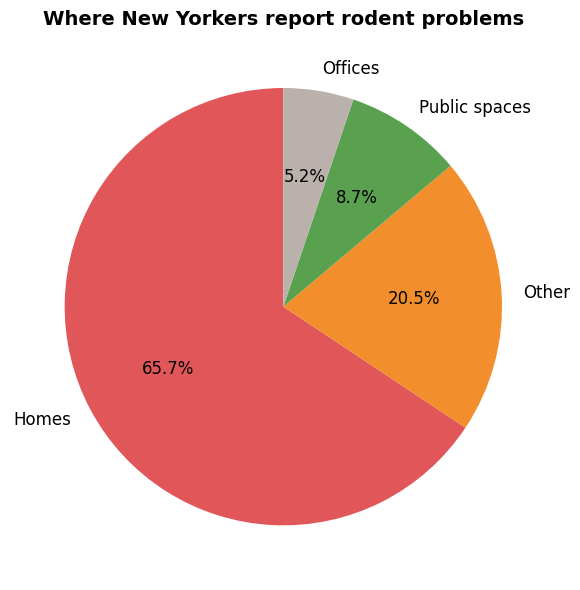

category
Homes            166980
Other             52085
Public spaces     22043
Offices           13188
Name: count, dtype: int64

In [342]:
import matplotlib.pyplot as plt

# Group location types into 3 categories
def categorize(loc):
    if pd.isna(loc):
        return "Other"
    homes = ["3+ Family Apt. Building", "1-2 Family Dwelling", 
             "3+ Family Mixed Use Building", "1-2 Family Mixed Use Building"]
    offices = ["Commercial Building", "Office Building", "Government Building"]
    public = ["Park", "Street/Curbside", "Vacant Lot", "Catch Basin/Sewer",
              "Construction Site", "Parking Lot/Garage"]
    if loc in homes:
        return "Homes"
    elif loc in offices:
        return "Offices"
    elif loc in public:
        return "Public spaces"
    else:
        return "Other"

df["category"] = df["Location Type"].apply(categorize)
cat_counts = df["category"].value_counts()

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
colors = ["#e15759", "#f28e2b", "#59a14f", "#bab0ac"]
ax.pie(cat_counts, labels=cat_counts.index, autopct="%1.1f%%", 
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Where New Yorkers report rodent problems", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

cat_counts

In [343]:
# Most rodent-infested streets
top_streets = (df.groupby(["Street Name", "Borough"])
               .size()
               .reset_index(name="complaints")
               .sort_values("complaints", ascending=False))
top_streets.head(20)

,Street Name,Borough,complaints
312,2 AVENUE,MANHATTAN,6141
1717,BROADWAY,MANHATTAN,1643
967,AMSTERDAM AVENUE,MANHATTAN,1353
1429,BEDFORD AVENUE,BROOKLYN,1157
572,5 AVENUE,MANHATTAN,1022
7527,WOODYCREST AVENUE,BRONX,928
3719,GRAND CONCOURSE,BRONX,925
6269,ST JOHNS PLACE,BROOKLYN,905
5230,OCEAN AVENUE,BROOKLYN,898
1490,BERGEN STREET,BROOKLYN,794


In [344]:
# Most rodent-infested blocks (street + cross streets)
top_blocks = (df.dropna(subset=["Street Name", "Cross Street 1", "Cross Street 2"])
              .groupby(["Street Name", "Cross Street 1", "Cross Street 2", "Borough"])
              .size()
              .reset_index(name="complaints")
              .sort_values("complaints", ascending=False))
top_blocks.head(20)

,Street Name,Cross Street 1,Cross Street 2,Borough,complaints
3457,2 AVENUE,EAST 123 STREET,EAST 124 STREET,MANHATTAN,4454
46912,WOODYCREST AVENUE,WEST 162 STREET,WEST 163 STREET,BRONX,854
3524,2 AVENUE,JESUS TATO LAVIERA WAY,EAST 124 STREET,MANHATTAN,763
7028,5 AVENUE,EAST 81 STREET,EAST 82 STREET,MANHATTAN,594
2305,150 STREET,BARCLAY AVENUE,SANFORD AVENUE,QUEENS,506
44851,WEST 116 STREET,ST NICHOLAS AVENUE,FREDERICK DOUGLASS BOULEVARD,MANHATTAN,469
44768,WEST 109 STREET,AMSTERDAM AVENUE,BROADWAY,MANHATTAN,423
40968,ST JOHNS PLACE,UNDERHILL AVENUE,WASHINGTON AVENUE,BROOKLYN,312
44760,WEST 108 STREET,AMSTERDAM AVENUE,BROADWAY,MANHATTAN,283
44763,WEST 108 STREET,CENTRAL PARK WEST,MANHATTAN AVENUE,MANHATTAN,266


In [345]:
# Look up BBL and addresses for the 2 Ave / E 123 St / E 124 St block
block_match = df[
    (df["Street Name"] == "2 AVENUE") &
    (df["Cross Street 1"] == "EAST 123 STREET") &
    (df["Cross Street 2"] == "EAST 124 STREET")
]
print(f"{len(block_match)} complaints on this block\n")

# Parse BBL into Borough, Block, Lot for NYC Property Information Portal
bbls = block_match["BBL"].dropna().unique()
for bbl in bbls:
    bbl_str = str(int(bbl)).zfill(10)
    borough = {"1": "Manhattan", "2": "Bronx", "3": "Brooklyn", "4": "Queens", "5": "Staten Island"}[bbl_str[0]]
    block = bbl_str[1:6].lstrip("0")
    lot = bbl_str[6:10].lstrip("0")
    print(f"BBL: {bbl_str} → Borough: {borough}, Block: {block}, Lot: {lot}")

print()
print("Addresses:")
print(block_match["Incident Address"].value_counts())

4454 complaints on this block

BBL: 1017970001 → Borough: Manhattan, Block: 1797, Lot: 1
BBL: 1017880027 → Borough: Manhattan, Block: 1788, Lot: 27

Addresses:
Incident Address
2400 2 AVENUE    4449
2410 2 AVENUE       4
2411 2 AVENUE       1
Name: count, dtype: int64


In [346]:
# Breakdown of 2 Ave / E 123 St / E 124 St block complaints

print("=== By complaint type ===")
print(block_match["Problem Detail (formerly Descriptor)"].value_counts())

print("\n=== By location type ===")
print(block_match["Location Type"].value_counts())

print("\n=== By status ===")
print(block_match["Status"].value_counts())

print("\n=== By year ===")
print(block_match["Created Date"].dt.year.value_counts().sort_index())

print("\n=== By month (all years) ===")
print(block_match["Created Date"].dt.month_name().value_counts())

=== By complaint type ===
Problem Detail (formerly Descriptor)
Signs of Rodents    4451
Rat Sighting           3
Name: count, dtype: int64

=== By location type ===
Location Type
3+ Family Apt. Building    4454
Name: count, dtype: int64

=== By status ===
Status
Closed    4454
Name: count, dtype: int64

=== By year ===
Created Date
2020       2
2022      50
2023    1290
2024    1882
2025    1230
Name: count, dtype: int64

=== By month (all years) ===
Created Date
July         510
August       475
April        410
May          390
June         385
January      372
December     371
September    368
November     320
October      306
March        278
February     269
Name: count, dtype: int64


In [347]:
# Check if Additional Details has more info for this block
print(block_match["Additional Details"].dropna().value_counts())
print(f"\n{block_match['Additional Details'].isna().sum()} out of {len(block_match)} have no additional details")

Series([], Name: count, dtype: int64)

4454 out of 4454 have no additional details


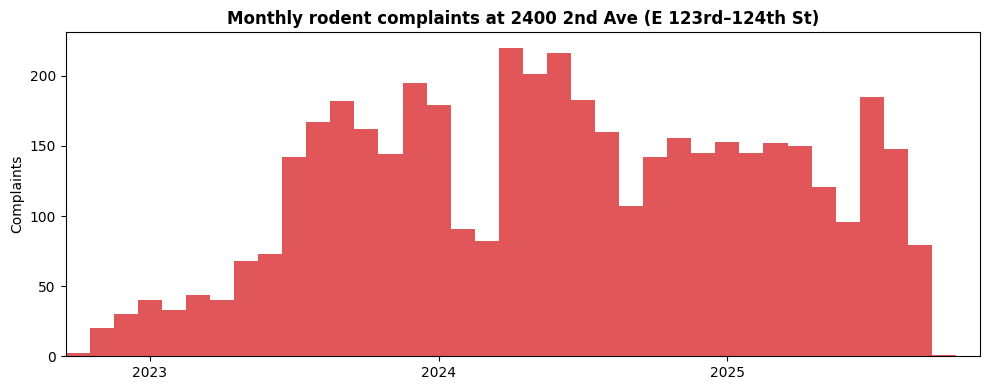

In [348]:
# Time series of complaints for this block
block_monthly = block_match.groupby(block_match["Created Date"].dt.to_period("M")).size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(block_monthly)), block_monthly.values, width=1, color="#e15759")
ax.set_title("Monthly rodent complaints at 2400 2nd Ave (E 123rd–124th St)", fontsize=12, fontweight="bold")
ax.set_ylabel("Complaints")
ax.set_xlim(-0.5, len(block_monthly) + 0.5)

# Show only Jan ticks
tick_labels = block_monthly.index.astype(str).tolist()
jan_indices = [i for i, t in enumerate(tick_labels) if t.endswith("-01")]
ax.set_xticks(jan_indices)
ax.set_xticklabels([tick_labels[i][:4] for i in jan_indices])

plt.tight_layout()
plt.show()

In [349]:
# Check: any 2026 complaints on this block?
print("This block in 2026:")
print(block_match[block_match["Created Date"].dt.year == 2026]["Created Date"].dt.month.value_counts().sort_index())

print("\nAll of df in 2026 (by month):")
print(df[df["Created Date"].dt.year == 2026]["Created Date"].dt.month.value_counts().sort_index())

This block in 2026:
Series([], Name: count, dtype: int64)

All of df in 2026 (by month):
Created Date
1    1668
2    1398
3    2611
4    2762
5    3656
Name: count, dtype: int64


In [350]:
# Check neighboring blocks around E 123rd St / 2nd Ave
nearby_streets = ["1 AVENUE", "2 AVENUE", "3 AVENUE", "LEXINGTON AVENUE"]
nearby_cross = ["EAST 121 STREET", "EAST 122 STREET", "EAST 123 STREET", 
                "EAST 124 STREET", "EAST 125 STREET", "EAST 126 STREET"]

neighbors = df[
    (df["Street Name"].isin(nearby_streets)) & 
    (df["Cross Street 1"].isin(nearby_cross) | df["Cross Street 2"].isin(nearby_cross))
]

# Compare 2025 vs 2026 complaint counts by block
neighbors_by_year = (neighbors
    .groupby(["Street Name", "Cross Street 1", "Cross Street 2", 
              neighbors["Created Date"].dt.year])
    .size()
    .unstack(fill_value=0))

# Show only 2025 and 2026 columns
cols = [c for c in neighbors_by_year.columns if c in [2024, 2025, 2026]]
result = neighbors_by_year[cols].copy()
result["change"] = result.get(2026, 0) - result.get(2025, 0)
result = result.sort_values(2025, ascending=False)
print(f"Neighboring blocks around E 123rd & 2nd Ave:\n")
result.head(20)

Neighboring blocks around E 123rd & 2nd Ave:



Created Date                                                              2024  \
Street Name      Cross Street 1         Cross Street 2                           
2 AVENUE         EAST 123 STREET        EAST 124 STREET                   1882   
LEXINGTON AVENUE EAST 125 STREET        EAST 126 STREET                      2   
                 EAST 123 STREET        EAST 124 STREET                      5   
                 EAST 122 STREET        EAST 123 STREET                      1   
2 AVENUE         2 AVENUE               EAST 121 STREET                      0   
3 AVENUE         EAST 125 STREET        EAST 126 STREET                      1   
LEXINGTON AVENUE EAST 124 STREET        EAST 125 STREET                      0   
                 EAST 121 STREET        EAST 122 STREET                      4   
                 EAST 120 STREET        EAST 121 STREET                      0   
3 AVENUE         EAST 126 STREET        EAST 127 STREET                      0   
                 EAST 123 STREET        EAST 124 STREET                      0   
2 AVENUE         EAST 121 STREET        EAST 122 STREET                      0   
3 AVENUE         EAST 121 STREET        ALFREDO CHOCOLATE ARMENTEROS WAY     0   
                 3 AVENUE               EAST 126 STREET                      0   
                                        EAST 124 STREET                      1   
2 AVENUE         JESUS TATO LAVIERA WAY EAST 124 STREET                      0   
                 EAST 124 STREET        EAST 125 STREET                      0   
                 EAST 122 STREET        JESUS TATO LAVIERA WAY               0   
                                        EAST 123 STREET                      1   
LEXINGTON AVENUE YOLANDA SANCHEZ PLACE  EAST 121 STREET                      0   

Created Date                                                              2025  \
Street Name      Cross Street 1         Cross Street 2                           
2 AVENUE         EAST 123 STREET        EAST 124 STREET                   1230   
LEXINGTON AVENUE EAST 125 STREET        EAST 126 STREET                      3   
                 EAST 123 STREET        EAST 124 STREET                      1   
                 EAST 122 STREET        EAST 123 STREET                      1   
2 AVENUE         2 AVENUE               EAST 121 STREET                      0   
3 AVENUE         EAST 125 STREET        EAST 126 STREET                      0   
LEXINGTON AVENUE EAST 124 STREET        EAST 125 STREET                      0   
                 EAST 121 STREET        EAST 122 STREET                      0   
                 EAST 120 STREET        EAST 121 STREET                      0   
3 AVENUE         EAST 126 STREET        EAST 127 STREET                      0   
                 EAST 123 STREET        EAST 124 STREET                      0   
2 AVENUE         EAST 121 STREET        EAST 122 STREET                      0   
3 AVENUE         EAST 121 STREET        ALFREDO CHOCOLATE ARMENTEROS WAY     0   
                 3 AVENUE               EAST 126 STREET                      0   
                                        EAST 124 STREET                      0   
2 AVENUE         JESUS TATO LAVIERA WAY EAST 124 STREET                      0   
                 EAST 124 STREET        EAST 125 STREET                      0   
                 EAST 122 STREET        JESUS TATO LAVIERA WAY               0   
                                        EAST 123 STREET                      0   
LEXINGTON AVENUE YOLANDA SANCHEZ PLACE  EAST 121 STREET                      0   

Created Date                                                              2026  \
Street Name      Cross Street 1         Cross Street 2                           
2 AVENUE         EAST 123 STREET        EAST 124 STREET                      0   
LEXINGTON AVENUE EAST 125 STREET        EAST 126 STREET                      1   
                 EAST 123 STREET        EAST 124 STREET       

In [351]:
# Blocks with biggest swings in complaints: Jan-May across 2023, 2024, 2025, 2026
years = [2023, 2024, 2025, 2026]
group_cols = ["Street Name", "Cross Street 1", "Cross Street 2", "Borough"]

counts = {}
for y in years:
    subset = df[(df["Created Date"].dt.year == y) & (df["Created Date"].dt.month <= 5)]
    counts[y] = (subset.dropna(subset=group_cols[:3])
                 .groupby(group_cols).size().reset_index(name=f"jan_may_{y}"))

swings = counts[2023]
for y in years[1:]:
    swings = swings.merge(counts[y], on=group_cols, how="outer")
swings = swings.fillna(0)
for y in years:
    swings[f"jan_may_{y}"] = swings[f"jan_may_{y}"].astype(int)
swings["change_25_to_26"] = swings["jan_may_2026"] - swings["jan_may_2025"]

print("=== BIGGEST DROPS (improved?) ===")
display(swings.sort_values("change_25_to_26").head(15))

print("\n=== BIGGEST SPIKES (got worse) ===")
display(swings.sort_values("change_25_to_26", ascending=False).head(15))

=== BIGGEST DROPS (improved?) ===


,Street Name,Cross Street 1,Cross Street 2,Borough,jan_may_2023,jan_may_2024,jan_may_2025,jan_may_2026,change_25_to_26
1307,2 AVENUE,EAST 123 STREET,EAST 124 STREET,MANHATTAN,225,773,721,0,-721
19076,WEST 109 STREET,AMSTERDAM AVENUE,BROADWAY,MANHATTAN,25,9,65,7,-58
15981,QUEENS BOULEVARD,55 AVENUE,55 ROAD,QUEENS,0,0,44,0,-44
19953,WESTMINSTER ROAD,CATON AVENUE,CHURCH AVENUE,BROOKLYN,6,16,48,6,-42
19217,WEST 135 STREET,ADAM CLAYTON POWELL JR BOULEVARD,FREDERICK DOUGLASS BOULEVARD,MANHATTAN,3,1,33,1,-32
18940,WEST 77 STREET,CENTRAL PARK ENTRANCE W 77 ST,COLUMBUS AVENUE,MANHATTAN,0,10,28,1,-27
8478,EAST 5 STREET,GREENWOOD AVENUE,PROSPECT EXPRESSWAY EXIT 5 EB,BROOKLYN,0,0,26,0,-26
19097,WEST 112 STREET,ST NICHOLAS AVENUE,ADAM CLAYTON POWELL JR BOULEVARD,MANHATTAN,3,5,27,3,-24
15896,PROSPECT PLACE,CLASSON AVENUE,FRANKLIN AVENUE SHUTTLE LINE,BROOKLYN,4,1,25,1,-24
19383,WEST 172 STREET,BROADWAY,FORT WASHINGTON AVENUE,MANHATTAN,8,1,25,1,-24



=== BIGGEST SPIKES (got worse) ===


,Street Name,Cross Street 1,Cross Street 2,Borough,jan_may_2023,jan_may_2024,jan_may_2025,jan_may_2026,change_25_to_26
11064,FORT HAMILTON PARKWAY,85 STREET,86 STREET,BROOKLYN,1,0,0,57,57
11702,GRAND CONCOURSE,EAST 183 STREET,FIELD PLACE,BRONX,2,0,1,52,51
20225,WOODYCREST AVENUE,WEST 162 STREET,WEST 163 STREET,BRONX,17,31,181,232,51
17496,STEINWAY STREET,DITMARS BOULEVARD,23 AVENUE,QUEENS,5,1,0,41,41
7031,CARROLL STREET,WASHINGTON AVENUE,CARROLL ST PEDESTRIAN OVERPASS,BROOKLYN,3,4,7,39,32
18026,UNION STREET,NOSTRAND AVENUE,NEW YORK AVENUE,BROOKLYN,0,0,19,47,28
8474,EAST 5 STREET,COOPER SQUARE,2 AVENUE,MANHATTAN,5,8,14,42,28
4923,AMSTERDAM AVENUE,WEST 88 STREET,WEST 89 STREET,MANHATTAN,7,1,25,51,26
969,160 STREET,78 AVENUE,78 ROAD,QUEENS,0,0,0,25,25
7660,CONEY ISLAND AVENUE,PARKVILLE AVENUE,FOSTER AVENUE,BROOKLYN,1,1,0,25,25


In [352]:
# Same swing analysis by address
years = [2023, 2024, 2025, 2026]
addr_cols = ["Incident Address", "Borough"]

addr_counts = {}
for y in years:
    subset = df[(df["Created Date"].dt.year == y) & (df["Created Date"].dt.month <= 5)]
    addr_counts[y] = (subset.dropna(subset=["Incident Address"])
                      .groupby(addr_cols).size().reset_index(name=f"jan_may_{y}"))

addr_swings = addr_counts[2023]
for y in years[1:]:
    addr_swings = addr_swings.merge(addr_counts[y], on=addr_cols, how="outer")
addr_swings = addr_swings.fillna(0)
for y in years:
    addr_swings[f"jan_may_{y}"] = addr_swings[f"jan_may_{y}"].astype(int)
addr_swings["change_25_to_26"] = addr_swings["jan_may_2026"] - addr_swings["jan_may_2025"]

print("=== BIGGEST DROPS BY ADDRESS ===")
display(addr_swings.sort_values("change_25_to_26").head(15))

print("\n=== BIGGEST SPIKES BY ADDRESS ===")
display(addr_swings.sort_values("change_25_to_26", ascending=False).head(15))

=== BIGGEST DROPS BY ADDRESS ===


,Incident Address,Borough,jan_may_2023,jan_may_2024,jan_may_2025,jan_may_2026,change_25_to_26
13839,2400 2 AVENUE,MANHATTAN,231,825,719,0,-719
32547,87-18 QUEENS BOULEVARD,QUEENS,0,0,42,0,-42
31855,83 EAST 5 STREET,BROOKLYN,0,0,26,0,-26
16857,30 WESTMINSTER ROAD,BROOKLYN,0,9,30,4,-26
23416,45-02 DITMARS BOULEVARD,QUEENS,0,0,20,0,-20
32011,84 LAWRENCE AVENUE,BROOKLYN,0,0,20,0,-20
24719,50 WEST 77 STREET,MANHATTAN,1,4,20,1,-19
28435,642 WEST 172 STREET,MANHATTAN,3,0,20,1,-19
7091,16 OLD BROADWAY,MANHATTAN,1,10,21,3,-18
8237,172 EAST 112 STREET,MANHATTAN,0,2,17,0,-17



=== BIGGEST SPIKES BY ADDRESS ===


,Incident Address,Borough,jan_may_2023,jan_may_2024,jan_may_2025,jan_may_2026,change_25_to_26
32261,8501 FORT HAMILTON PARKWAY,BROOKLYN,1,0,0,53,53
13308,2337 GRAND CONCOURSE,BRONX,2,0,0,51,51
12239,22-55 STEINWAY STREET,QUEENS,0,1,0,41,41
26924,589 AMSTERDAM AVENUE,MANHATTAN,5,1,18,51,33
33903,963 WOODYCREST AVENUE,BRONX,5,1,79,110,31
31075,78-04 160 STREET,QUEENS,0,0,0,25,25
33496,932 CARROLL STREET,BROOKLYN,0,3,4,27,23
725,1032 CONEY ISLAND AVENUE,BROOKLYN,0,0,0,22,22
31469,800 GREENWOOD AVENUE,BROOKLYN,0,0,0,22,22
33823,957 WOODYCREST AVENUE,BRONX,9,29,99,119,20


## Scope for the Svelte project

**Top 5 addresses by number of complaints with the biggest spike and the biggest drop, so in total, I will have 10 small multiples.**

Each small multiple will show jan-may counts for that address, so we can also include 2026 for most current comparison. We will have jan-may data for four years: 2023, 2024, 2025 and 2026.

## Step 1: Build data for small multiples chart
Pick top 5 biggest drops and top 5 biggest spikes by address (Jan–May, 2025 vs 2026). Then get monthly Jan–May counts for each across 2023–2026.

In [353]:
# Pick top 5 drops and top 5 spikes from addr_swings
top_drops = addr_swings.sort_values("change_25_to_26").head(5)
top_spikes = addr_swings.sort_values("change_25_to_26", ascending=False).head(5)

selected = pd.concat([top_drops, top_spikes])
print("Selected addresses:")
display(selected[["Incident Address", "Borough", "jan_may_2025", "jan_may_2026", "change_25_to_26"]])

Selected addresses:


,Incident Address,Borough,jan_may_2025,jan_may_2026,change_25_to_26
13839,2400 2 AVENUE,MANHATTAN,719,0,-719
32547,87-18 QUEENS BOULEVARD,QUEENS,42,0,-42
31855,83 EAST 5 STREET,BROOKLYN,26,0,-26
16857,30 WESTMINSTER ROAD,BROOKLYN,30,4,-26
23416,45-02 DITMARS BOULEVARD,QUEENS,20,0,-20
32261,8501 FORT HAMILTON PARKWAY,BROOKLYN,0,53,53
13308,2337 GRAND CONCOURSE,BRONX,0,51,51
12239,22-55 STEINWAY STREET,QUEENS,0,41,41
26924,589 AMSTERDAM AVENUE,MANHATTAN,18,51,33
33903,963 WOODYCREST AVENUE,BRONX,79,110,31


In [354]:
# Build monthly Jan-May data for each selected address across 2023-2026
import json

addresses = selected[["Incident Address", "Borough"]].values.tolist()
jan_may = df[df["Created Date"].dt.month <= 5].copy()
jan_may["year"] = jan_may["Created Date"].dt.year
jan_may["month"] = jan_may["Created Date"].dt.month

chart_data = []
for addr, boro in addresses:
    subset = jan_may[(jan_may["Incident Address"] == addr) & (jan_may["Borough"] == boro)]
    monthly = subset.groupby(["year", "month"]).size().reset_index(name="count")
    
    # Determine if spike or drop
    row = selected[(selected["Incident Address"] == addr) & (selected["Borough"] == boro)].iloc[0]
    change = int(row["change_25_to_26"])
    
    entry = {
        "address": addr,
        "borough": boro,
        "change": change,
        "type": "spike" if change > 0 else "drop",
        "months": monthly.to_dict(orient="records")
    }
    chart_data.append(entry)

# Sort: drops first (most negative), then spikes (most positive)
chart_data.sort(key=lambda x: x["change"])

print(f"{len(chart_data)} addresses ready for chart")
for d in chart_data:
    print(f"  {d['type'].upper():5s} ({d['change']:+d}) — {d['address']}, {d['borough']}")
    
chart_data[0]  # preview first entry

10 addresses ready for chart
  DROP  (-719) — 2400 2 AVENUE, MANHATTAN
  DROP  (-42) — 87-18 QUEENS BOULEVARD, QUEENS
  DROP  (-26) — 83 EAST    5 STREET, BROOKLYN
  DROP  (-26) — 30 WESTMINSTER ROAD, BROOKLYN
  DROP  (-20) — 45-02 DITMARS BOULEVARD, QUEENS
  SPIKE (+31) — 963 WOODYCREST AVENUE, BRONX
  SPIKE (+33) — 589 AMSTERDAM AVENUE, MANHATTAN
  SPIKE (+41) — 22-55 STEINWAY STREET, QUEENS
  SPIKE (+51) — 2337 GRAND CONCOURSE, BRONX
  SPIKE (+53) — 8501 FORT HAMILTON PARKWAY, BROOKLYN


{'address': '2400 2 AVENUE',
 'borough': 'MANHATTAN',
 'change': -719,
 'type': 'drop',
 'months': [{'year': 2021, 'month': 1, 'count': 5},
  {'year': 2021, 'month': 3, 'count': 3},
  {'year': 2021, 'month': 4, 'count': 6},
  {'year': 2021, 'month': 5, 'count': 7},
  {'year': 2022, 'month': 1, 'count': 32},
  {'year': 2022, 'month': 2, 'count': 45},
  {'year': 2022, 'month': 3, 'count': 65},
  {'year': 2022, 'month': 4, 'count': 54},
  {'year': 2022, 'month': 5, 'count': 74},
  {'year': 2023, 'month': 1, 'count': 40},
  {'year': 2023, 'month': 2, 'count': 33},
  {'year': 2023, 'month': 3, 'count': 45},
  {'year': 2023, 'month': 4, 'count': 41},
  {'year': 2023, 'month': 5, 'count': 72},
  {'year': 2024, 'month': 1, 'count': 179},
  {'year': 2024, 'month': 2, 'count': 101},
  {'year': 2024, 'month': 3, 'count': 82},
  {'year': 2024, 'month': 4, 'count': 262},
  {'year': 2024, 'month': 5, 'count': 201},
  {'year': 2025, 'month': 1, 'count': 153},
  {'year': 2025, 'month': 2, 'count': 145

In [355]:
# Step 2: Export to JSON for Svelte
import os

out_dir = "../src/lib/data"
os.makedirs(out_dir, exist_ok=True)

with open(f"{out_dir}/rat-hotspots.json", "w") as f:
    json.dump(chart_data, f, indent=2)

print(f"Saved {len(chart_data)} addresses to src/lib/data/rat-hotspots.json")

Saved 10 addresses to src/lib/data/rat-hotspots.json
